# Fig 1 viualization

In [ ]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from src.plot_utils import format_axis

RESULTS_ROOT = Path("../../../results/icl_copy_firstlast/runs")

## 1. Multi-Seed Analysis

Load a group run (created with `--n_seeds N`) and plot mean ± std across seeds.

In [2]:
def load_group_results(results_dir: Path, identifier: str) -> list:
    """
    Load all seed results from a group directory (created with --n_seeds N).

    Args:
        results_dir: Root results directory (RESULTS_ROOT).
        identifier:  Substring that uniquely identifies the group dir name,
                     e.g. "20260225120000_n5seeds" or just "n5seeds".

    Returns:
        List of results dicts, one per seed, each with a '_source_dir' key.
    """
    group_dir = None
    for d in sorted(results_dir.iterdir()):
        if d.is_dir() and identifier in d.name:
            group_dir = d
            break
    if group_dir is None:
        raise FileNotFoundError(f"No group dir matching '{identifier}' in {results_dir}")

    seed_results = []
    for seed_dir in sorted(group_dir.iterdir()):
        if not seed_dir.is_dir():
            continue
        results_file = seed_dir / "results.json"
        if not results_file.exists():
            continue
        with open(results_file) as f:
            data = json.load(f)
        data['_source_dir'] = str(seed_dir)
        seed_results.append(data)
    
    if len(seed_results) == 0:
        results_file = group_dir / "results.json"
        if results_file.exists():
            with open(results_file) as f:
                data = json.load(f)
            data['_source_dir'] = str(group_dir)
            seed_results.append(data)

    if not seed_results:
        raise FileNotFoundError(f"No seed subdirs with results.json found in {group_dir}")

    print(f"Loaded {len(seed_results)} seeds from: {group_dir}")
    return seed_results


## 2. Helper

In [3]:
def _align_to_length(arrays: list) -> np.ndarray:
    """Truncate all arrays to the shortest length and stack into (n_seeds, T)."""
    min_len = min(len(a) for a in arrays)
    return np.stack([np.array(a[:min_len]) for a in arrays])

## 5. Figure 1 plot

Loaded 30 seeds from: ../../../results/icl_copy_firstlast/runs/20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds
10% Copy-First (curriculum): 30 seeds passed 90% filter
Loaded 30 seeds from: ../../../results/icl_copy_firstlast/runs/20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds
50% Copy-First (uniform): 30 seeds passed 90% filter


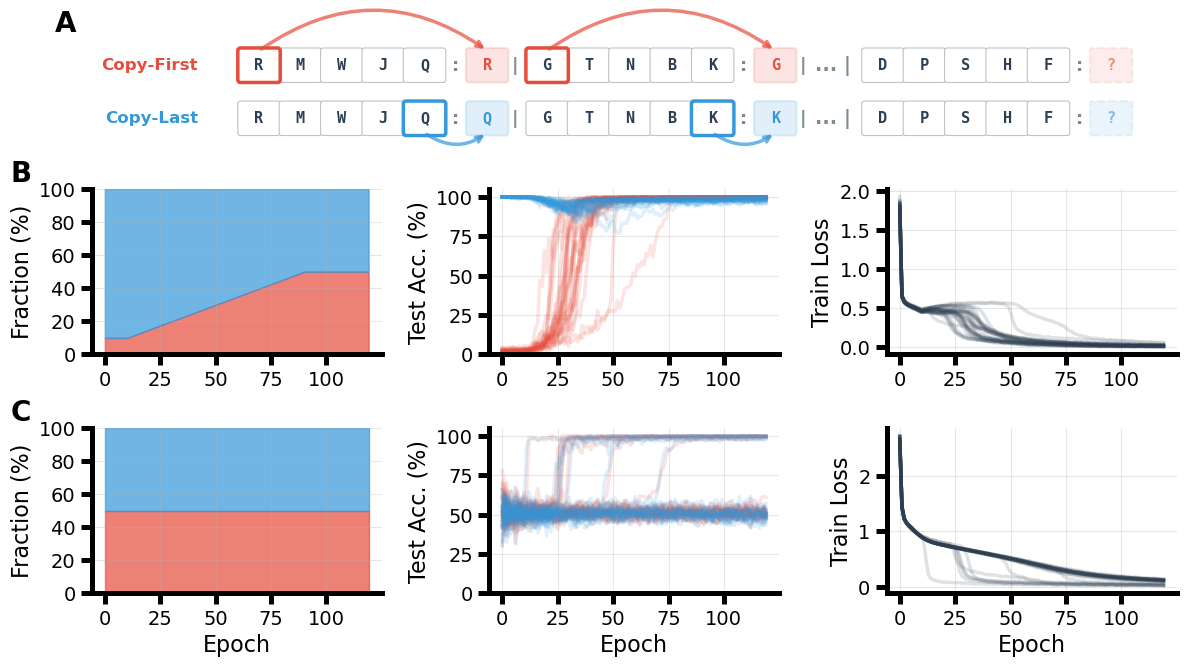

In [ ]:
# ── Figure: Task + Training Curves ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

CF_COLOR = '#e74c3c'
CL_COLOR = '#3498db'
STRUCT_COLOR = '#7f8c8d'
FEAT_BG = '#ffffff'

# ── Panel A: Task visualization ──────────────────────────────────────────────

ctx_features = [
    ['R', 'M', 'W', 'J', 'Q'],
    ['G', 'T', 'N', 'B', 'K'],
]
query_feature = ['D', 'P', 'S', 'H', 'F']

def draw_task_row(ax, task, ctx_features, query_feature, y_center=0):
    color = CF_COLOR if task == 'copy_first' else CL_COLOR
    label = "Copy-First" if task == 'copy_first' else "Copy-Last"
    src_idx = 0 if task == 'copy_first' else -1

    box_w, box_h = 0.7, 0.55
    gap = 0.08
    x = 0.0

    arrow_sources = []
    arrow_targets = []

    for ex_i, feat in enumerate(ctx_features):
        for tok_i, tok in enumerate(feat):
            bx = x
            rect = mpatches.FancyBboxPatch(
                (bx, y_center - box_h / 2), box_w, box_h,
                boxstyle="round,pad=0.05", facecolor=FEAT_BG,
                edgecolor='#bdc3c7', linewidth=0.8, zorder=1)
            ax.add_patch(rect)
            ax.text(bx + box_w / 2, y_center, tok,
                    ha='center', va='center', fontsize=11, fontfamily='monospace',
                    fontweight='bold', color='#2c3e50', zorder=3)

            if tok_i == (0 if task == 'copy_first' else len(feat) - 1):
                highlight = mpatches.FancyBboxPatch(
                    (bx, y_center - box_h / 2), box_w, box_h,
                    boxstyle="round,pad=0.05", facecolor='none',
                    edgecolor=color, linewidth=2.5, zorder=2)
                ax.add_patch(highlight)
                arrow_sources.append(bx + box_w / 2)

            x += box_w + gap

        ax.text(x + 0.15, y_center, ':', ha='center', va='center',
                fontsize=13, fontweight='bold', color=STRUCT_COLOR)
        x += 0.4

        lbl = feat[src_idx]
        lbl_x = x
        rect = mpatches.FancyBboxPatch(
            (lbl_x, y_center - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05", facecolor=color, alpha=0.15,
            edgecolor=color, linewidth=1.5, zorder=1)
        ax.add_patch(rect)
        ax.text(lbl_x + box_w / 2, y_center, lbl,
                ha='center', va='center', fontsize=11, fontfamily='monospace',
                fontweight='bold', color=color, zorder=3)
        arrow_targets.append(lbl_x + box_w / 2)
        x += box_w + gap

        ax.text(x + 0.1, y_center, '|', ha='center', va='center',
                fontsize=13, fontweight='bold', color=STRUCT_COLOR)
        x += 0.35

    # Ellipsis
    ax.text(x + 0.3, y_center, '... |', ha='center', va='center',
            fontsize=14, fontweight='bold', color=STRUCT_COLOR)
    x += 0.9

    # Query
    for tok_i, tok in enumerate(query_feature):
        bx = x
        rect = mpatches.FancyBboxPatch(
            (bx, y_center - box_h / 2), box_w, box_h,
            boxstyle="round,pad=0.05", facecolor=FEAT_BG,
            edgecolor='#bdc3c7', linewidth=0.8, zorder=1)
        ax.add_patch(rect)
        ax.text(bx + box_w / 2, y_center, tok,
                ha='center', va='center', fontsize=11, fontfamily='monospace',
                fontweight='bold', color='#2c3e50', zorder=3)

        # if tok_i == (0 if task == 'copy_first' else len(query_feature) - 1):
        #     highlight = mpatches.FancyBboxPatch(
        #         (bx, y_center - box_h / 2), box_w, box_h,
        #         boxstyle="round,pad=0.05", facecolor='none',
        #         edgecolor=color, linewidth=2.5, zorder=2)
        #     ax.add_patch(highlight)
        #     arrow_sources.append(bx + box_w / 2)

        x += box_w + gap

    ax.text(x + 0.15, y_center, ':', ha='center', va='center',
            fontsize=13, fontweight='bold', color=STRUCT_COLOR)
    x += 0.4
    q_x = x
    rect = mpatches.FancyBboxPatch(
        (q_x, y_center - box_h / 2), box_w, box_h,
        boxstyle="round,pad=0.05", facecolor=color, alpha=0.10,
        edgecolor=color, linewidth=1.5, linestyle='--', zorder=1)
    ax.add_patch(rect)
    ax.text(q_x + box_w / 2, y_center, '?',
            ha='center', va='center', fontsize=11, fontfamily='monospace',
            fontweight='bold', color=color, alpha=0.6, zorder=3)
    arrow_targets.append(q_x + box_w / 2)
    x += box_w + gap

    arrow_sign = 1 if task == 'copy_first' else -1
    for src_x, tgt_x in zip(arrow_sources, arrow_targets):
        ax.annotate(
            '', xy=(tgt_x, y_center + arrow_sign * box_h / 2),
            xytext=(src_x, y_center + arrow_sign * box_h / 2),
            arrowprops=dict(
                arrowstyle='->', color=color, lw=2.5,
                connectionstyle=f'arc3,rad={-0.35 * arrow_sign}',
                alpha=0.7))

    ax.text(-0.8, y_center, label, ha='right', va='center',
            fontsize=12, fontweight='bold', color=color)
    return x

# ── Load data ────────────────────────────────────────────────────────────────
# main runs in paper
run_configs = [
    ("10% Copy-First (curriculum)", "20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds"),
    ("50% Copy-First (uniform)",    "20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds"),
]

all_results = {}
for label, identifier in run_configs:
    seed_results = load_group_results(RESULTS_ROOT, identifier)
    # seed_results = [r for r in seed_results
    #                 if r['pretraining']['final_metrics']['copy_first_accuracy'] >= 0.9
    #                 and r['pretraining']['final_metrics']['copy_last_accuracy'] >= 0.9]
    all_results[label] = seed_results
    print(f"{label}: {len(seed_results)} seeds passed 90% filter")

# ── Build figure ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1.0, 1.2, 1.2],
                       hspace=0.47, wspace=0.37)

# Panel A — task visualization (spans full top row)
ax_task = fig.add_subplot(gs[0, :])
w = draw_task_row(ax_task, 'copy_first', ctx_features, query_feature, y_center=0.5)
draw_task_row(ax_task, 'copy_last', ctx_features, query_feature, y_center=-0.5)
ax_task.set_xlim(-2.5, w + 0.5)
ax_task.set_ylim(-1.2, 1.4)
ax_task.set_aspect('equal')
ax_task.axis('off')
ax_task.text(-3.5, 1.55, 'A', fontsize=20, fontweight='bold', va='top',
             transform=ax_task.transData)

# Move Panel A slightly downward
pos = ax_task.get_position()
ax_task.set_position([
    pos.x0,
    pos.y0 - 0.05,  # decrease this more to move further down
    pos.width,
    pos.height,
])

# Panels B–G: 2 rows × 3 cols (Accuracy, Loss, Task Mixture)
col_titles = ['Accuracy', 'Training Loss', 'Task Mixture']
row_labels = list(all_results.keys())
# panel_letters = ['B', 'C', 'D', 'E', 'F', 'G']
panel_letters = ['B', 'C']

for row_i, (row_label, seed_results) in enumerate(all_results.items()):
    if len(seed_results) < 1:
        continue

    cf_acc_list, cl_acc_list, loss_list = [], [], []
    for r in seed_results:
        pt = r['pretraining']
        cf_acc_list.append(pt['copy_first_accuracy'])
        cl_acc_list.append(pt['copy_last_accuracy'])
        loss_list.append(pt['train_loss'])

    cf_arr   = _align_to_length(cf_acc_list) * 100
    cl_arr   = _align_to_length(cl_acc_list) * 100
    loss_arr = _align_to_length(loss_list)
    epochs   = np.arange(cf_arr.shape[1])

    for col_i in range(3):
        ax = fig.add_subplot(gs[row_i + 1, col_i])

        # # Panel letter — top-left in axes coords
        # ax.text(-0.28, 1.18, letter, fontsize=20, fontweight='bold',
        #         transform=ax.transAxes, va='top')

        if col_i == 0:  # Task mixture

            cf_frac = np.array(seed_results[0]['pretraining']['copy_first_frac']) * 100
            mix_epochs = np.arange(len(cf_frac))
            ax.fill_between(mix_epochs, 0, cf_frac, alpha=0.7,
                            label='Copy First', color=CF_COLOR)
            ax.fill_between(mix_epochs, cf_frac, 100, alpha=0.7,
                            label='Copy Last', color=CL_COLOR)
            ax.set_ylabel('Fraction (%)')
            ax.set_ylim(0, 100)

            # Panel letter — top-left in axes coords
            letter = panel_letters[row_i]
            ax.text(-0.28, 1.18, letter, fontsize=20, fontweight='bold',
                    transform=ax.transAxes, va='top')
            # ax.legend(fontsize=8, loc='lower right')

        elif col_i == 1:  # accuracy
            for arr, color, lbl in [(cf_arr, CF_COLOR, 'Copy First'),
                                    (cl_arr, CL_COLOR, 'Copy Last')]:
                # mean, std = arr.mean(0), arr.std(0)
                # ax.plot(epochs, mean, color=color, linewidth=2, label=lbl)
                for s in arr:
                    ax.plot(epochs, s, color=color, alpha=0.15, linewidth=0.6)
            ax.set_ylabel('Test Acc. (%)')
            ax.set_ylim(0, 105)
            letter = panel_letters[row_i]

        elif col_i == 2:  # Training loss
            # mean, std = loss_arr.mean(0), loss_arr.std(0)
            # ax.plot(epochs, mean, color='#2c3e50', linewidth=2)
            # ax.fill_between(epochs, mean - std, mean + std,
            #                 color='#2c3e50', alpha=0.15)
            for s in loss_arr:
                ax.plot(epochs, s, color='#2c3e50', alpha=0.15, linewidth=0.6)
            ax.set_ylabel('Train Loss')


        # if col_i == 2 and row_i == 0:
        #     ax.legend(fontsize=7, loc='upper right')

        ax.set_xlabel('Epoch')
        ax.grid(alpha=0.3)
        format_axis(ax, line_width_multiplier=1.8, font_size_multiplier=1)
        if row_i == 0:
            # remove the x-axis label for the top row
            ax.set_xlabel('')
plt.show()